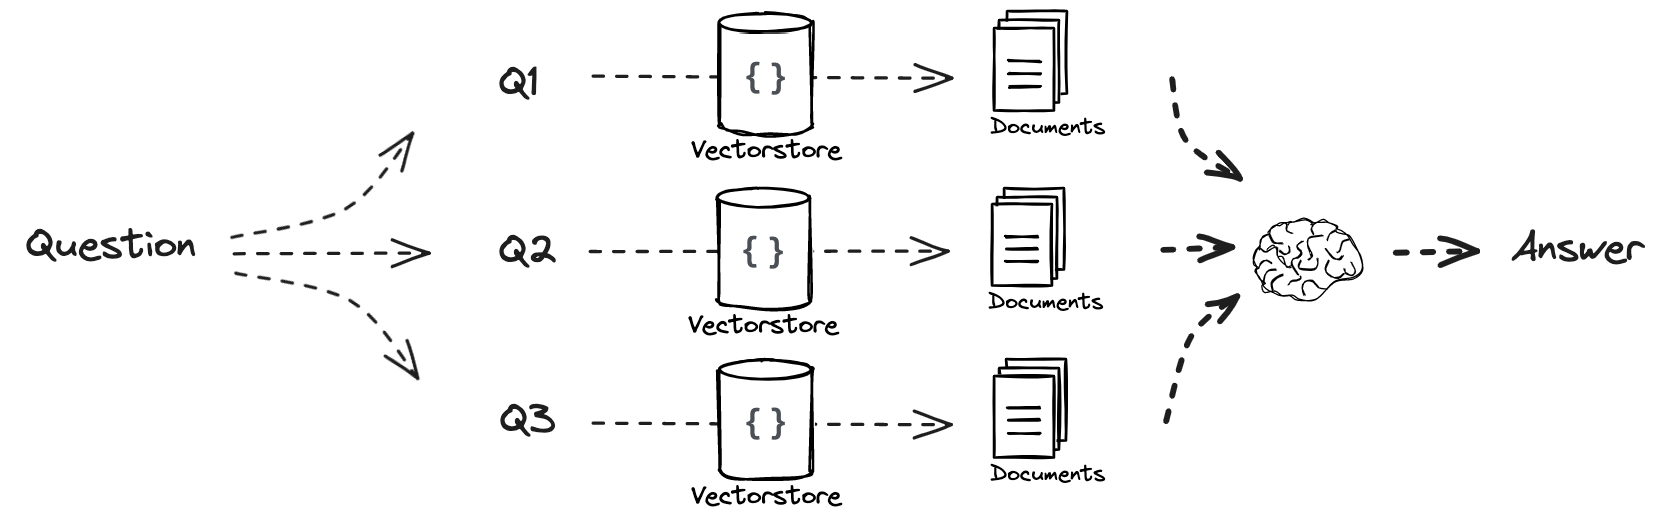

STEPS
1.Indexing
    a. load
    b. split
    c. store
2. retreive
3. Prompt Generate
4. documnet process(if required)
5. chain

In [47]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import os
from dotenv import load_dotenv
load_dotenv()



True

LOAD

In [41]:
pyloadwe=PyPDFLoader(file_path='../data/guidlines.pdf')
loader=pyloadwe.load_and_split()
loader

[Document(metadata={'source': '../data/guidlines.pdf', 'page': 0}, page_content="Scala Coding Guidelines  \nQuantexa Coding Guidelines:  \nGeneral \nScala/Spark   \nCamel Case  Use camel casing, not underscores! Vals/vars/methods(defs) should all \nbe lowerCamelCase, types/objects should all be UpperCamelCase (also \nknown as ProperCase), for further details please  see this style guide .  \nExceptions  \n1. In ETL processes, the raw data should be read into a parquet \nmaintaining all of the source field names exactly.   \n2. Constant values - use ProperCase. For example, val YearInDays = \n365 \n3. When using acronyms and camel case, if it is the first word \nwithin a variable name it should be lower case, if it is not the first \nword, it should be all upper case. E.G:  \no jiraTaskDescription (and not JIRATaskDescription)  \no accountIBAN (and not accountIban)  \n4. When using acronyms and proper case,  every letter of the \nacronym should be upper case, e.g.  \no case class ETLCon

SPLIT

In [50]:
splits=RecursiveCharacterTextSplitter(chunk_size=300)
docs=splits.split_documents(loader)
docs

[Document(metadata={'source': '../data/guidlines.pdf', 'page': 0}, page_content='Scala Coding Guidelines  \nQuantexa Coding Guidelines:  \nGeneral \nScala/Spark   \nCamel Case  Use camel casing, not underscores! Vals/vars/methods(defs) should all \nbe lowerCamelCase, types/objects should all be UpperCamelCase (also'),
 Document(metadata={'source': '../data/guidlines.pdf', 'page': 0}, page_content='General \nScala/Spark   \nCamel Case  Use camel casing, not underscores! Vals/vars/methods(defs) should all \nbe lowerCamelCase, types/objects should all be UpperCamelCase (also \nknown as ProperCase), for further details please  see this style guide .  \nExceptions'),
 Document(metadata={'source': '../data/guidlines.pdf', 'page': 0}, page_content='be lowerCamelCase, types/objects should all be UpperCamelCase (also \nknown as ProperCase), for further details please  see this style guide .  \nExceptions  \n1. In ETL processes, the raw data should be read into a parquet \nmaintaining all of the

STORE


In [53]:
emb=OpenAIEmbeddings(api_key=os.getenv('token'),model='text-embedding-3-small')
store=Chroma.from_documents(embedding=emb,documents=docs)
store

In [ ]:
#Retreiver

In [54]:
ret=store.as_retriever()
ret

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x000001E4E1011190>)

In [56]:
model=ChatOpenAI(model=os.getenv('model_name'),api_key=os.getenv('token'),temperature=0)

PROMPT

In [58]:
# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""
prompt_perspectives = ChatPromptTemplate.from_template(template)

generate_queries = (
    prompt_perspectives 
    | model 
    | StrOutputParser() 
    | (lambda x: x.split("\n"))
)
#generate_queries.invoke("scala coding standards?")

['1. What are the best practices for writing Scala code?',
 '2. How can I ensure my Scala code follows industry coding standards?',
 '3. What guidelines should I follow when writing Scala code?',
 '4. Are there any recommended coding conventions for Scala development?',
 '5. How can I improve the quality of my Scala code through coding standards?']

Fetch the documents which has relavant information based on Questions

In [60]:
from langchain.load import dumps, loads

def get_unique_union(documents: list[list]):
    """ Unique union of retrieved docs """
    # Flatten list of lists, and convert each Document to string
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Get unique documents
    unique_docs = list(set(flattened_docs))
    # Return
    return [loads(doc) for doc in unique_docs]

# Retrieve
retrieval_chain = generate_queries | ret.map() | get_unique_union
#question = "scala coding standards?"
#docs = retrieval_chain.invoke({"question":question})
#docs

[Document(metadata={'page': 4, 'source': '../data/guidlines.pdf'}, page_content='http://www.lihaoyi.com/post/StrategicScalaStylePracticalTypeSafety.html  \nhttps://pavelfatin.com/scala -collections -tips-and-tricks/  \nhttps://github.com/alexandru/scala -best -practices  \nhttps://twitter.github.io/scala_school/'),
 Document(metadata={'page': 1, 'source': '../data/guidlines.pdf'}, page_content='General \nScala/Spark   \nComments  If you need to comment your code to explain something, instead \nquestion whether you can write the code in a clearer way (generally the \nway to do this should result in more functional code).  Good code should'),
 Document(metadata={'page': 3, 'source': '../data/guidlines.pdf'}, page_content='when doing ad -hoc coding work before moving it into an etl/scoring \nproject.  \nExternal comprehensive coding guidelines:  \nhttp://docs.scala -lang.org/style/  \nhttps://github.com/alexandru/scala -best -practices'),
 Document(metadata={'page': 0, 'source': '../data/

Finally based on filters context execute find the best Answer

In [61]:
from operator import itemgetter
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain, 
     "question": itemgetter("question")} 
    | prompt
    | model
    | StrOutputParser()
)

final_rag_chain.invoke({"question":'scala coding standards'})

'The Scala coding standards mentioned in the provided context include using camel casing, avoiding underscores, and questioning the need for comments in code by striving for clearer and more functional code. Additional external comprehensive coding guidelines are also recommended for reference.'